In [57]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

from imblearn.over_sampling import SMOTE

In [58]:
# =========================
# 2. Load Dataset
# =========================
df = pd.read_csv(
    r"C:\Users\20130\Downloads\Burnout_Data\student_lifestyle_100k.csv"
)

print(df.head())

print("\nDataset Shape:")
print(df.shape)

   Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science  3.50             7.3          3.3   
1        1002   20    Male  Engineering  2.72             5.5          7.2   
2        1003   20    Male      Medical  3.01             5.4          2.3   
3        1004   21    Male  Engineering  3.63             8.1          2.0   
4        1005   19    Male         Arts  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  

Dataset Shape:
(100000, 11)


In [59]:
# =========================
# 3. Sample 10k Rows
# =========================
df = df.sample(
    n=10000,
    random_state=42
).reset_index(drop=True)

print("\nSampled Dataset Shape:")
print(df.shape)


Sampled Dataset Shape:
(10000, 11)


In [60]:
# =========================
# 4. Features and Target
# =========================
X = df.drop(columns=["Depression", "Student_ID"])

y = df["Depression"].astype(int)

print("\nTarget Distribution:")
print(y.value_counts())


Target Distribution:
Depression
0    9009
1     991
Name: count, dtype: int64


In [61]:
# =========================
# 5. Column Types
# =========================
categorical_cols = [
    "Gender",
    "Department"
]

numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols
]

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)


Categorical Columns:
['Gender', 'Department']

Numerical Columns:
['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']


In [62]:
# =========================
# 6. Preprocessing
# =========================
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ]
)

In [63]:
# =========================
# 7. Train / Validation / Test Split
# =========================

# First split:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25,   # 0.25 of 0.8 = 0.2
    random_state=42,
    stratify=y_train_full
)

print("Training Size:", len(X_train))
print("Validation Size:", len(X_val))
print("Test Size:", len(X_test))

Training Size: 6000
Validation Size: 2000
Test Size: 2000


In [64]:
# =========================
# 8. Apply Preprocessing
# =========================
X_train_scaled = preprocessor.fit_transform(X_train)

X_val_scaled = preprocessor.transform(X_val)

X_test_scaled = preprocessor.transform(X_test)

In [65]:
# =========================
# 9. Apply SMOTE
# =========================
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nBalanced Class Distribution:")
print(pd.Series(y_train_bal).value_counts())


Balanced Class Distribution:
Depression
1    5405
0    5405
Name: count, dtype: int64


In [66]:
# =========================
# 10. Hyperparameter Tuning
# =========================
best_k = 0
best_auc = 0

for k in range(3, 21, 2):

    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights="distance"
    )

    knn.fit(X_train_bal, y_train_bal)

    y_val_prob = knn.predict_proba(X_val_scaled)[:, 1]

    auc_score = roc_auc_score(
        y_val,
        y_val_prob
    )

    print(f"K={k}, Validation ROC-AUC={auc_score:.4f}")

    if auc_score > best_auc:
        best_auc = auc_score
        best_k = k

print("\nBest K:", best_k)
print("Best Validation ROC-AUC:", round(best_auc, 4))

K=3, Validation ROC-AUC=0.5285
K=5, Validation ROC-AUC=0.5540
K=7, Validation ROC-AUC=0.5578
K=9, Validation ROC-AUC=0.5590
K=11, Validation ROC-AUC=0.5603
K=13, Validation ROC-AUC=0.5622
K=15, Validation ROC-AUC=0.5642
K=17, Validation ROC-AUC=0.5672
K=19, Validation ROC-AUC=0.5657

Best K: 17
Best Validation ROC-AUC: 0.5672


In [67]:
# =========================
# 11. Train Final Model
# =========================
knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="distance"
)

knn.fit(X_train_bal, y_train_bal)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",17
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [68]:
# =========================
# 12. Predictions
# =========================
y_pred = knn.predict(X_test_scaled)

y_prob = knn.predict_proba(X_test_scaled)[:, 1]

# Threshold tuning
y_pred_thresh = (y_prob > 0.3).astype(int)

In [69]:
# =========================
# 13. Standard Evaluation
# =========================
print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob))

Accuracy:
0.6075

Confusion Matrix:
[[1110  692]
 [  93  105]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.62      0.74      1802
           1       0.13      0.53      0.21       198

    accuracy                           0.61      2000
   macro avg       0.53      0.57      0.47      2000
weighted avg       0.84      0.61      0.69      2000


ROC-AUC:
0.6048694492090718


In [70]:
# =========================
# 14. Threshold Evaluation
# =========================
print("\n--- Threshold = 0.3 ---")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_thresh))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_thresh
))


--- Threshold = 0.3 ---

Confusion Matrix:
[[ 707 1095]
 [  57  141]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.39      0.55      1802
           1       0.11      0.71      0.20       198

    accuracy                           0.42      2000
   macro avg       0.52      0.55      0.37      2000
weighted avg       0.85      0.42      0.52      2000



In [71]:
# =========================
# 15. Random Test Case
# =========================
random_index = np.random.randint(0, len(X_test))

original_sample = X_test.iloc[random_index]

sample_scaled = X_test_scaled[random_index].reshape(1, -1)

actual = y_test.iloc[random_index]

prediction = knn.predict(sample_scaled)[0]

probability = knn.predict_proba(sample_scaled)[0][1]

print("\nOriginal Features:")
print(original_sample)

print("\nActual:", actual)

print("Predicted:", prediction)

print("Probability of Depression:",
      round(probability, 4))

label = (
    "Depressed"
    if prediction == 1
    else "Not Depressed"
)

print("Prediction Label:", label)


Original Features:
Age                        19
Gender                 Female
Department            Science
CGPA                     2.06
Sleep_Duration            6.5
Study_Hours               1.7
Social_Media_Hours        7.3
Physical_Activity         111
Stress_Level                4
Name: 3702, dtype: object

Actual: 0
Predicted: 1
Probability of Depression: 0.8141
Prediction Label: Depressed


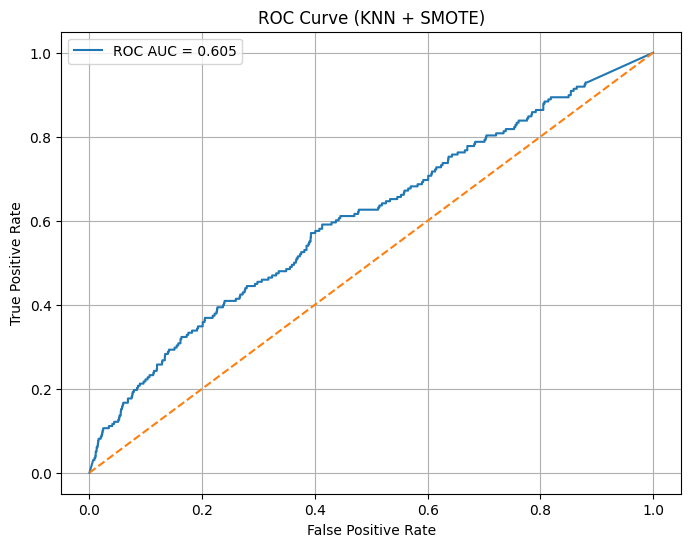

In [72]:
# =========================
# 16. ROC Curve
# =========================
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"ROC AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve (KNN + SMOTE)")

plt.legend()

plt.grid(True)

plt.show()

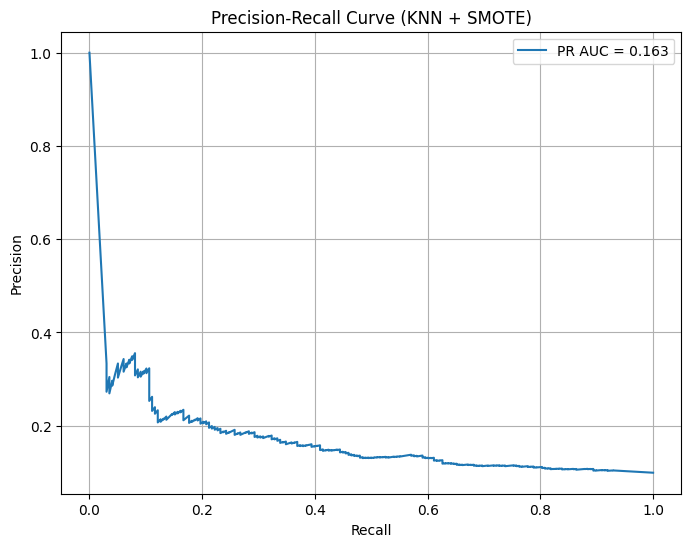

PR AUC: 0.1633


In [73]:
# =========================
# 17. Precision-Recall Curve
# =========================
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = average_precision_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    label=f"PR AUC = {pr_auc:.3f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve (KNN + SMOTE)")

plt.legend()

plt.grid(True)

plt.show()

print("PR AUC:", round(pr_auc, 4))

In [74]:
# =========================
# 18. Final Outputs
# =========================
print("\n========== FINAL RESULTS ==========")

bal_acc = balanced_accuracy_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("\nBest K:")
print(best_k)

print("\nAccuracy:")
print(round(acc, 4))

print("\nBalanced Accuracy:")
print(round(bal_acc, 4))

print("\nROC-AUC:")
print(round(roc, 4))

# Safe PR AUC handling
if "pr_auc" in globals():
    print("\nPR AUC:")
    print(round(pr_auc, 4))
else:
    print("\nPR AUC: Not computed (run Chunk 17)")

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


========== FINAL RESULTS ==========

Best K:
17

Accuracy:
0.6075

Balanced Accuracy:
0.5731

ROC-AUC:
0.6049

PR AUC:
0.1633

Final Confusion Matrix:
[[1110  692]
 [  93  105]]
